## 03 Child Grouping using K-Means Clustering

This notebook applies **K-Means Clustering** to group children based on MUAC patterns.

Notebook 02 created rule-based nutritional condition labels using MUAC thresholds.

In this notebook, K-Means clustering is used as an unsupervised machine learning method to create data-driven child nutrition groups.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

## 2. Load Condition Dataset

This dataset comes from Notebook 02 after MUAC-based condition classification.

In [2]:
df = pd.read_csv("../data/condition_data.csv")

df["ID"] = df["ID"].astype(str)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (6785, 11)


,ID,GmpDate,Name_Original,Name,DOB_Original,DOB,MUAC,Age,Age_Months,Age_Diff,Condition
0,581415010001,2017-12-17,ff,ff,2017-12-17,2017-12-17,15.0,84.0,0.00,84.00,Good
1,581415010001,2017-12-28,hdkdj,ff,2017-12-28,2017-12-17,15.0,84.0,0.36,83.64,Good
2,581415010002,2017-12-17,rahim,gg,2017-12-17,2017-12-17,13.0,84.0,0.00,84.00,At Risk
3,581415010002,2017-12-28,ldjjd,gg,2017-12-28,2017-12-17,14.0,84.0,0.36,83.64,Good
4,581415010003,2017-12-28,ifjjfjk,ifjjfjk,2017-12-28,2017-12-28,13.0,84.0,0.00,84.00,At Risk


## 3. Check Required Columns

Before clustering, the required columns are checked.

In [3]:
required_columns = [
    "ID",
    "MUAC",
    "Age_Months",
    "Condition"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) > 0:
    raise ValueError(f"Missing columns: {missing_columns}")

print("All required columns are available.")

All required columns are available.


## 4. Why Clustering?

Notebook 02 used rule-based MUAC classification.

In this notebook, K-Means clustering is used to check whether machine learning can create meaningful child nutrition groups from the data.

Two models are compared:

1. MUAC Only
2. MUAC + Age_Months

The model with the better Silhouette Score will be selected.

## 5. Model A: K-Means using MUAC Only

This model clusters children based only on MUAC values.

In [4]:
features_muac = ["MUAC"]

X_muac = df[features_muac].copy()

scaler_muac = StandardScaler()
X_muac_scaled = scaler_muac.fit_transform(X_muac)

X_muac_scaled_df = pd.DataFrame(
    X_muac_scaled,
    columns=["MUAC_Scaled"]
)

X_muac_scaled_df.head()

,MUAC_Scaled
0,0.638973
1,0.638973
2,-0.311056
3,0.163959
4,-0.311056


In [5]:
kmeans_muac = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster_MUAC_Original"] = kmeans_muac.fit_predict(X_muac_scaled)

muac_score = silhouette_score(
    X_muac_scaled,
    df["Cluster_MUAC_Original"]
)

print("MUAC Only Silhouette Score:", round(muac_score, 4))

MUAC Only Silhouette Score: 0.5743


## 6. MUAC-Only Cluster Centers

The centers show the average MUAC value for each cluster.

In [6]:
muac_centers = scaler_muac.inverse_transform(
    kmeans_muac.cluster_centers_
)

muac_centers_df = pd.DataFrame(
    muac_centers,
    columns=["MUAC"]
)

muac_centers_df["Cluster_MUAC_Original"] = muac_centers_df.index

muac_centers_df

,MUAC,Cluster_MUAC_Original
0,13.332596,0
1,15.971032,1
2,8.916845,2


## 7. Model B: K-Means using MUAC and Age_Months

This model uses both MUAC and calculated age in months.

In [7]:
features_age_muac = [
    "MUAC",
    "Age_Months"
]

X_age_muac = df[features_age_muac].copy()

scaler_age_muac = StandardScaler()
X_age_muac_scaled = scaler_age_muac.fit_transform(X_age_muac)

X_age_muac_scaled_df = pd.DataFrame(
    X_age_muac_scaled,
    columns=[
        "MUAC_Scaled",
        "Age_Months_Scaled"
    ]
)

X_age_muac_scaled_df.head()

,MUAC_Scaled,Age_Months_Scaled
0,0.638973,-1.612966
1,0.638973,-1.568912
2,-0.311056,-1.612966
3,0.163959,-1.568912
4,-0.311056,-1.612966


In [8]:
kmeans_age_muac = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster_Age_MUAC"] = kmeans_age_muac.fit_predict(X_age_muac_scaled)

age_muac_score = silhouette_score(
    X_age_muac_scaled,
    df["Cluster_Age_MUAC"]
)

print("MUAC + Age_Months Silhouette Score:", round(age_muac_score, 4))

MUAC + Age_Months Silhouette Score: 0.3277


## 8. MUAC + Age_Months Cluster Centers

Cluster centers help understand how each model groups children.

In [9]:
age_muac_centers = scaler_age_muac.inverse_transform(
    kmeans_age_muac.cluster_centers_
)

age_muac_centers_df = pd.DataFrame(
    age_muac_centers,
    columns=features_age_muac
)

age_muac_centers_df["Cluster_Age_MUAC"] = age_muac_centers_df.index

age_muac_centers_df

,MUAC,Age_Months,Cluster_Age_MUAC
0,15.132512,8.232267,0
1,11.777137,6.966508,1
2,13.826993,19.614549,2


## 9. Compare Both Clustering Models

Higher Silhouette Score usually means better cluster separation.

In [10]:
comparison_df = pd.DataFrame({
    "Model": [
        "MUAC Only",
        "MUAC + Age_Months"
    ],
    "Silhouette_Score": [
        round(muac_score, 4),
        round(age_muac_score, 4)
    ]
})

comparison_df

,Model,Silhouette_Score
0,MUAC Only,0.5743
1,MUAC + Age_Months,0.3277


## 10. Final Model Selection

The MUAC Only model is selected if it produces a better Silhouette Score.

In this dataset, MUAC Only clustering gives better separation than MUAC + Age_Months.

Therefore, the final clustering model uses MUAC only.

In [11]:
if muac_score >= age_muac_score:
    selected_model = "MUAC Only"
    selected_score = muac_score
else:
    selected_model = "MUAC + Age_Months"
    selected_score = age_muac_score

print("Selected Clustering Model:", selected_model)
print("Selected Silhouette Score:", round(selected_score, 4))

Selected Clustering Model: MUAC Only
Selected Silhouette Score: 0.5743


## 11. Assign Meaningful Cluster Names

K-Means cluster numbers are not fixed.

For example, Cluster 1 can be Healthy and Cluster 0 can be Moderate Risk.

So the original K-Means cluster numbers are converted into report-friendly cluster numbers:

- 0 = Healthy
- 1 = Moderate Risk
- 2 = High Risk

In [12]:
# Sort MUAC-only clusters by MUAC center
cluster_order = muac_centers_df.sort_values("MUAC").copy()

# Lowest MUAC = High Risk
high_risk_cluster = int(cluster_order.iloc[0]["Cluster_MUAC_Original"])

# Middle MUAC = Moderate Risk
moderate_risk_cluster = int(cluster_order.iloc[1]["Cluster_MUAC_Original"])

# Highest MUAC = Healthy
healthy_cluster = int(cluster_order.iloc[2]["Cluster_MUAC_Original"])

# Convert original K-Means cluster number into final report-friendly cluster number
cluster_number_map = {
    healthy_cluster: 0,
    moderate_risk_cluster: 1,
    high_risk_cluster: 2
}

# Final cluster name
cluster_name_map = {
    0: "Healthy",
    1: "Moderate Risk",
    2: "High Risk"
}

df["Cluster"] = df["Cluster_MUAC_Original"].map(cluster_number_map)
df["Cluster_Name"] = df["Cluster"].map(cluster_name_map)

print("Original K-Means Cluster to Final Cluster Number:")
print(cluster_number_map)

print("\nFinal Cluster Meaning:")
print(cluster_name_map)

df[
    [
        "ID",
        "MUAC",
        "Condition",
        "Cluster",
        "Cluster_Name"
    ]
].head()

Original K-Means Cluster to Final Cluster Number:
{1: 0, 0: 1, 2: 2}

Final Cluster Meaning:
{0: 'Healthy', 1: 'Moderate Risk', 2: 'High Risk'}


,ID,MUAC,Condition,Cluster,Cluster_Name
0,581415010001,15.0,Good,0,Healthy
1,581415010001,15.0,Good,0,Healthy
2,581415010002,13.0,At Risk,1,Moderate Risk
3,581415010002,14.0,Good,1,Moderate Risk
4,581415010003,13.0,At Risk,1,Moderate Risk


## 12. Final Cluster Centers

This table shows the MUAC center for the final report-friendly cluster groups.

In [13]:
final_centers_df = (
    df.groupby(["Cluster", "Cluster_Name"])["MUAC"]
    .mean()
    .reset_index()
    .rename(columns={"MUAC": "Mean_MUAC"})
    .sort_values("Cluster")
)

final_centers_df

,Cluster,Cluster_Name,Mean_MUAC
0,0,Healthy,15.971032
1,1,Moderate Risk,13.332596
2,2,High Risk,8.916845


## 13. Cluster Distribution

This shows how many records belong to each ML-based cluster group.

In [14]:
cluster_distribution = (
    df["Cluster_Name"]
    .value_counts()
    .reindex(["Healthy", "Moderate Risk", "High Risk"])
)

cluster_distribution

Cluster_Name
Healthy          1550
Moderate Risk    4804
High Risk         431
Name: count, dtype: int64

In [15]:
cluster_distribution_percent = (
    df["Cluster_Name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reindex(["Healthy", "Moderate Risk", "High Risk"])
)

cluster_distribution_percent

Cluster_Name
Healthy          22.84
Moderate Risk    70.80
High Risk         6.35
Name: proportion, dtype: float64

## 14. Compare Rule-Based Condition and ML-Based Cluster

This table compares Notebook 02 rule-based condition labels with Notebook 03 K-Means cluster labels.

In [16]:
comparison_table = pd.crosstab(
    df["Condition"],
    df["Cluster_Name"]
)

comparison_table

Cluster_Name,Healthy,High Risk,Moderate Risk
Condition,,,
At Risk,0,0,1651
Good,1550,0,2389
Moderate,0,0,760
Severe,0,431,4


## 15. Visualization: Cluster Distribution

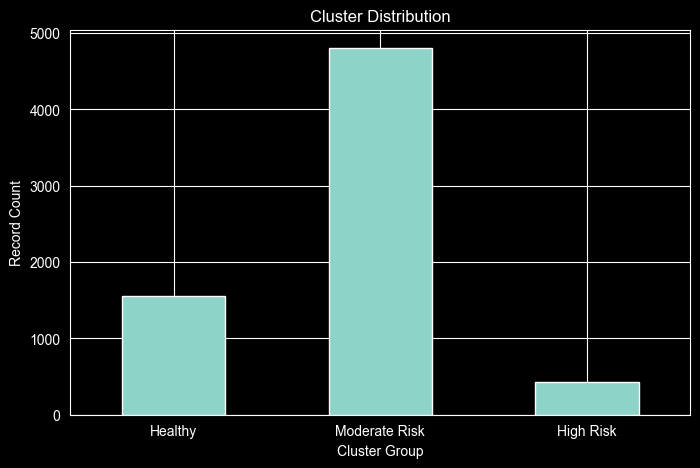

In [17]:
cluster_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Cluster Distribution")
plt.xlabel("Cluster Group")
plt.ylabel("Record Count")
plt.xticks(rotation=0)

plt.show()

## 16. Visualization: Model Comparison

This chart compares the Silhouette Scores of both clustering approaches.

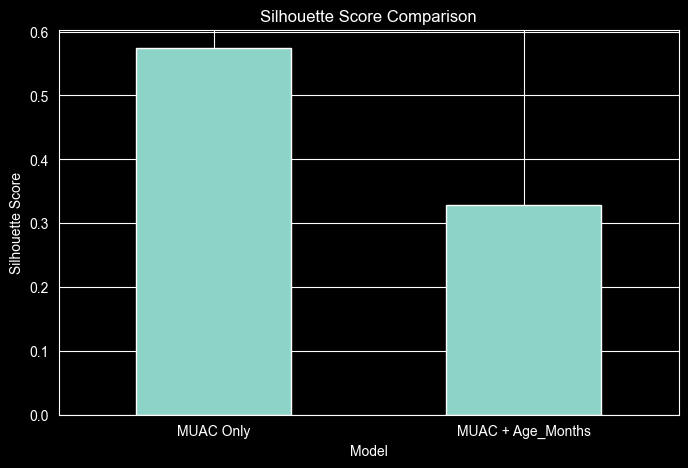

In [18]:
comparison_df.plot(
    x="Model",
    y="Silhouette_Score",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Silhouette Score Comparison")
plt.xlabel("Model")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=0)

plt.show()

## 17. Visualization: MUAC Distribution by Cluster

This boxplot shows how MUAC values are distributed across the final cluster groups.

<Figure size 800x500 with 0 Axes>

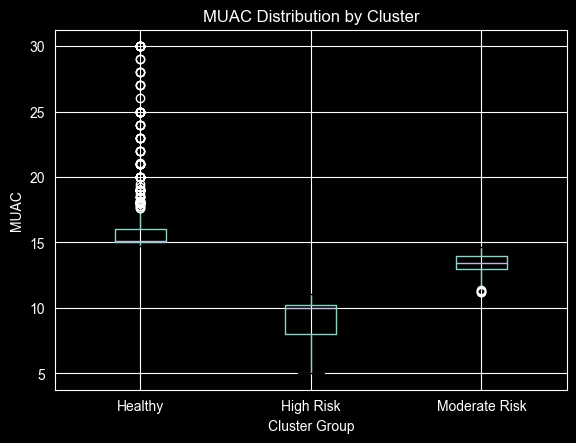

In [19]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="MUAC",
    by="Cluster_Name"
)

plt.title("MUAC Distribution by Cluster")
plt.suptitle("")
plt.xlabel("Cluster Group")
plt.ylabel("MUAC")

plt.show()

## 18. Optional Visualization: Age vs MUAC

The final model uses MUAC only.

Age_Months is shown here only as a reference visualization.

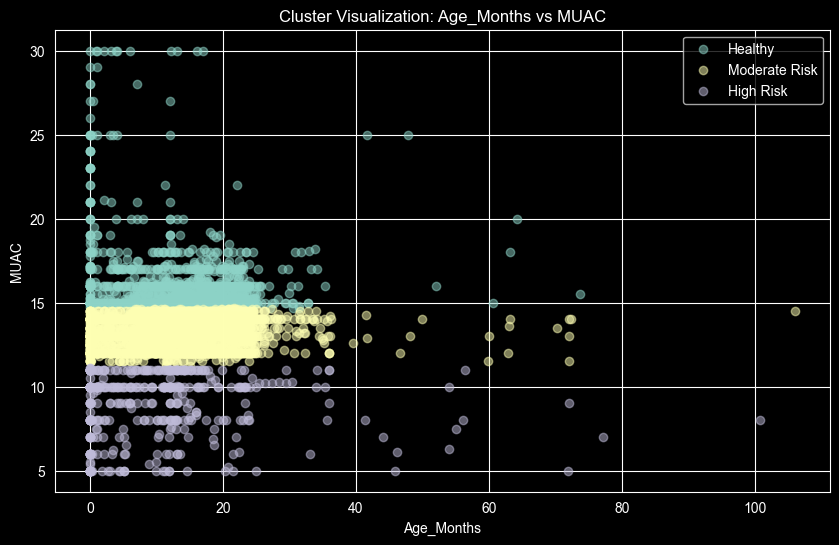

In [20]:
plt.figure(figsize=(10, 6))

for name in ["Healthy", "Moderate Risk", "High Risk"]:
    temp = df[df["Cluster_Name"] == name]

    plt.scatter(
        temp["Age_Months"],
        temp["MUAC"],
        label=name,
        alpha=0.5
    )

plt.legend()
plt.xlabel("Age_Months")
plt.ylabel("MUAC")
plt.title("Cluster Visualization: Age_Months vs MUAC")

plt.show()

## 19. Child-Level Cluster Check

This function helps check condition and cluster history for any child ID.

In [21]:
def get_child_cluster_history(child_id):

    child_id = str(child_id)

    available_columns = [
        "ID",
        "GmpDate",
        "Name_Original",
        "Name",
        "DOB_Original",
        "DOB",
        "MUAC",
        "Age_Months",
        "Condition",
        "Cluster",
        "Cluster_Name"
    ]

    available_columns = [
        col for col in available_columns
        if col in df.columns
    ]

    result = (
        df[df["ID"] == child_id]
        .sort_values("GmpDate")
    )

    if len(result) == 0:
        print("No records found for this Child ID")
        return None

    return result[available_columns]


get_child_cluster_history("581415010001")

,ID,GmpDate,Name_Original,Name,DOB_Original,DOB,MUAC,Age_Months,Condition,Cluster,Cluster_Name
0,581415010001,2017-12-17,ff,ff,2017-12-17,2017-12-17,15.0,0.00,Good,0,Healthy
1,581415010001,2017-12-28,hdkdj,ff,2017-12-28,2017-12-17,15.0,0.36,Good,0,Healthy


## 20. Save Clustered Dataset

The clustered dataset will be used in later notebooks for trend analysis and risk transition analysis.

In [22]:
output_path = "../data/clustered_data.csv"

df.to_csv(
    output_path,
    index=False
)

print("Clustered dataset saved:", output_path)

Clustered dataset saved: ../data/clustered_data.csv


## 21. Final Summary

In [23]:
summary = {
    "Total Records": len(df),
    "Total Children": df["ID"].nunique(),
    "Selected Model": selected_model,
    "Selected Silhouette Score": round(selected_score, 4),
    "Cluster 0": "Healthy",
    "Cluster 1": "Moderate Risk",
    "Cluster 2": "High Risk"
}

summary

{'Total Records': 6785,
 'Total Children': 3041,
 'Selected Model': 'MUAC Only',
 'Selected Silhouette Score': 0.5743,
 'Cluster 0': 'Healthy',
 'Cluster 1': 'Moderate Risk',
 'Cluster 2': 'High Risk'}